In [1]:
# Import required packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

In [31]:
# Create dataframe of data and show firt rows
df = pd.read_csv("data_full_story.csv")
df.head()

,name,story_score,agency_score,event_score,world_score,suspense_score,surprise_score,curiosity_score
0,t1_c95k50u,0.000000,1.0,1.0,1.000000,2.75,2.25,1.75
1,t1_c95mz3n,0.857143,4.0,5.0,1.000000,2.75,2.75,3.25
2,t1_c95l4my,0.857143,4.0,4.0,1.000000,2.75,3.25,3.50
3,t1_c95mcms,0.857143,5.0,5.0,1.000000,3.25,4.00,2.50
4,t3_1aenyc,1.000000,5.0,5.0,3.666667,2.75,3.50,3.75


In [32]:
len(df)

620

In [33]:
# Check out structure of dataset
print(df.info())

# Show summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             620 non-null    object 
 1   story_score      620 non-null    float64
 2   agency_score     620 non-null    float64
 3   event_score      620 non-null    float64
 4   world_score      620 non-null    float64
 5   suspense_score   620 non-null    float64
 6   surprise_score   620 non-null    float64
 7   curiosity_score  620 non-null    float64
dtypes: float64(7), object(1)
memory usage: 38.9+ KB
None


,story_score,agency_score,event_score,world_score,suspense_score,surprise_score,curiosity_score
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000
mean,0.414055,2.091935,2.037097,1.330108,2.440323,2.579839,2.762903
std,0.343393,1.404907,1.372429,0.768705,0.865481,0.842671,0.777586
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,1.000000,1.000000,1.750000,2.000000,2.250000
50%,0.428571,1.000000,1.000000,1.000000,2.500000,2.500000,2.750000
75%,0.714286,3.000000,3.000000,1.000000,3.000000,3.250000,3.250000
max,1.000000,5.000000,5.000000,4.666667,5.000000,5.000000,4.750000


In [34]:
# The dependent variable = story_score
y = df["story_score"]

# List of independent variables: agency_score, event_score, world_score, suspense_score, surprise_score and curiosity_score
features = [
    "agency_score",
    "event_score",
    "world_score",
    "suspense_score",
    "surprise_score",
    "curiosity_score"
]

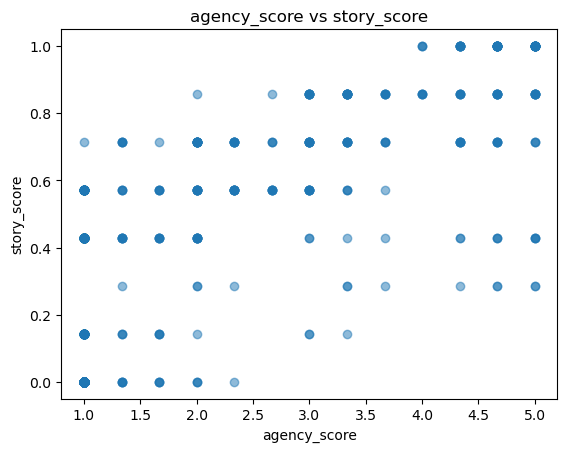

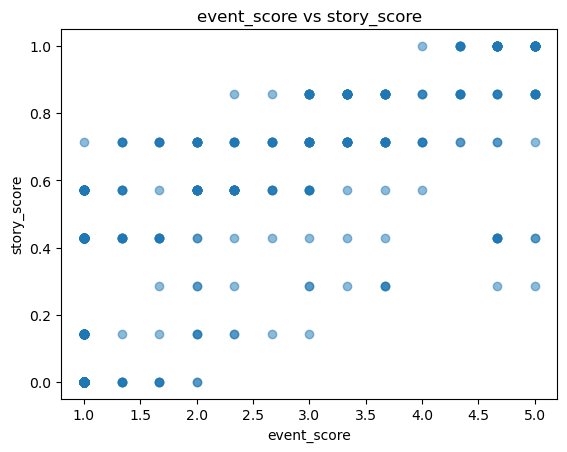

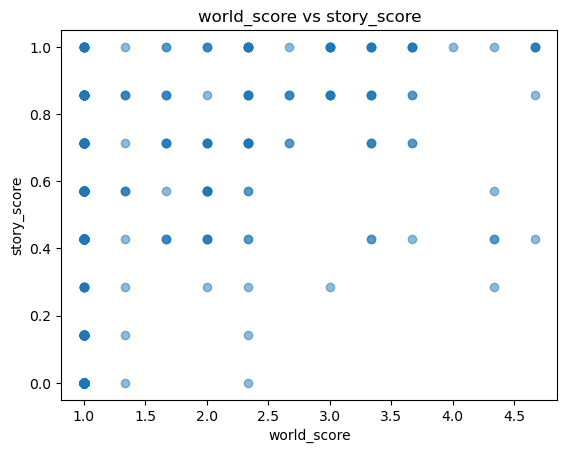

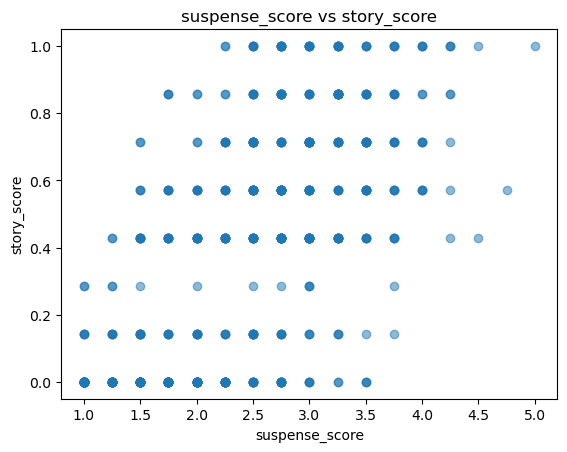

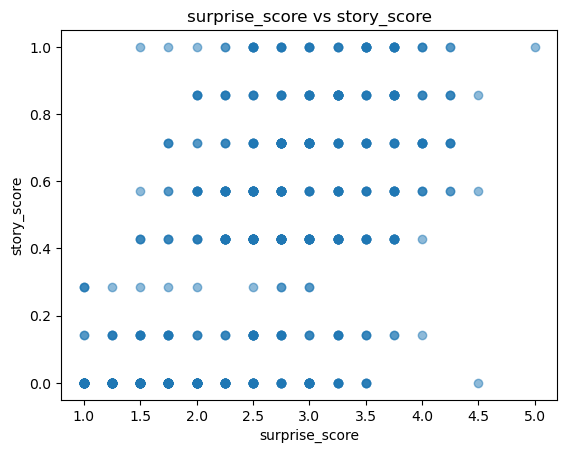

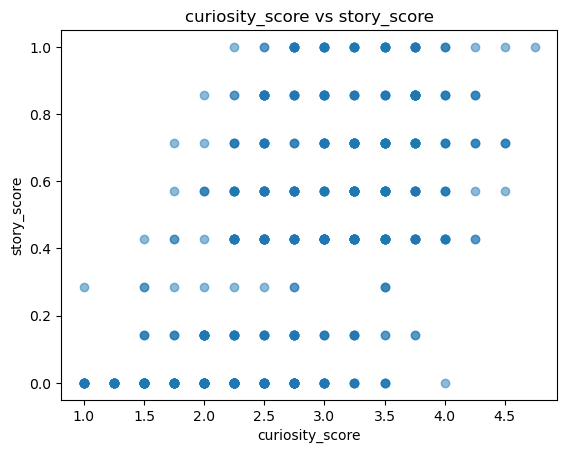

In [35]:
# Create scatterplots to visually inspect relationships
for feature in features:
    plt.figure()
    plt.scatter(df[feature], df["story_score"], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("story_score")
    plt.title(f"{feature} vs story_score")
    plt.show()

In [36]:
# Function for simple linear regression
def run_linear_regression(feature):
    print("Regression for:", feature, "\n")

    # Select one independent variable
    X = df[[feature]]

    # Split into training and test data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train linear regression model
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    # Make predictions
    results = lr.predict(X_test)

    # Print intercept and slope
    print("Intercept:", lr.intercept_)
    print("Slope:", lr.coef_[0])

    # Calculat R2 using sklearn
    r2_sklearn = r2_score(y_test, results)
    print("Sklearn R2 score:", r2_sklearn)

    # Plot regression line
    plt.figure()
    plt.scatter(X_test, y_test, alpha=0.5)
    plt.plot(X_test, results)
    plt.xlabel(feature)
    plt.ylabel("story_score")
    plt.title(f"Regression line for {feature}")
    plt.show()

    # Create dataframe with predictions and residuals
    results_df = pd.DataFrame()
    results_df["predicted"] = list(results)
    results_df["actual"] = list(y_test)
    results_df["residual"] = results_df["predicted"] - results_df["actual"]
    results_df = results_df.sort_values(by="residual").reset_index(drop=True)

    # Show summary statistics
    print(results_df.describe())

    # Histogram of residuals
    sns.histplot(data=results_df["residual"])
    plt.title("Histogram of Linear Regression Residuals")
    plt.show()

    # Predicted vs actual plot
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.scatter(results_df["actual"], results_df["predicted"], alpha=.35)
    plt.plot([0, 1], [0, 1], color="black")
    plt.title("Plot of Linear Regression Test Values, Predicted vs. Actual")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.subplots_adjust(top=0.85)
    plt.show()

    # Shapiro-Wilk test on residuals
    shapiro_test = stats.shapiro(results_df["residual"])
    print("Shapiro-Wilk test:")
    print("Statistic:", shapiro_test.statistic)
    print("p-value:", shapiro_test.pvalue)

    if shapiro_test.pvalue > 0.05:
        print("Residuals are approximately normally distributed")
    else:
        print("Residuals are NOT normally distributed")

    print("--------------------------------------------------------------------------------\n")

Regression for: agency_score 

Intercept: 0.040346928962693096
Slope: 0.17785720679617587
Sklearn R2 score: 0.6895229454490654


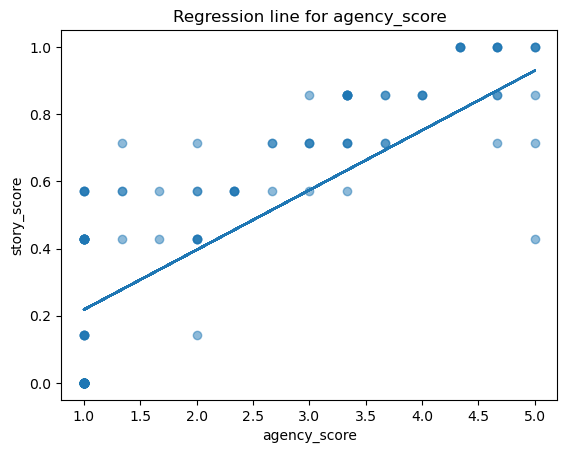

        predicted      actual    residual
count  124.000000  124.000000  124.000000
mean     0.418054    0.426267   -0.008213
std      0.247458    0.362953    0.202071
min      0.218204    0.000000   -0.436796
25%      0.218204    0.000000   -0.191617
50%      0.218204    0.428571   -0.044653
75%      0.633204    0.714286    0.218204
max      0.929633    1.000000    0.501062


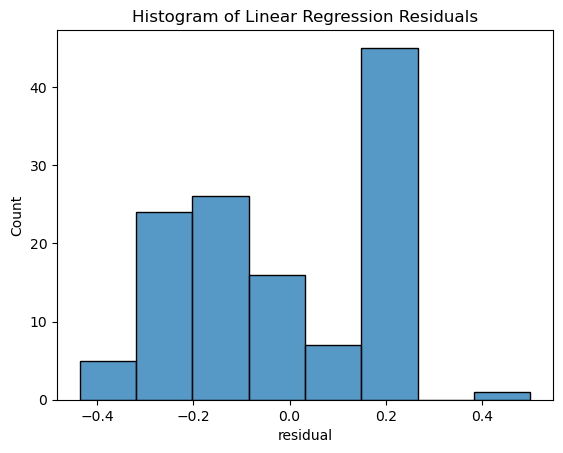

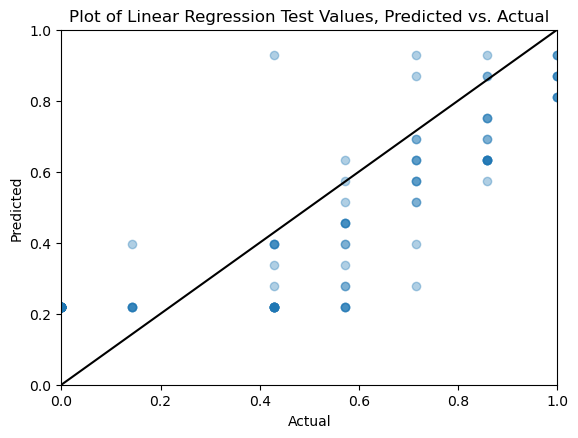

Shapiro-Wilk test:
Statistic: 0.8834181924591016
p-value: 2.031519670411929e-08
Residuals are NOT normally distributed
--------------------------------------------------------------------------------

Regression for: event_score 

Intercept: 0.03638750049472872
Slope: 0.18525318306256972
Sklearn R2 score: 0.6955173773158027


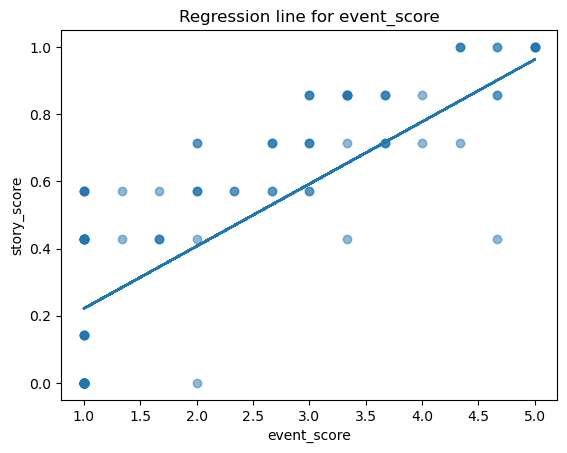

        predicted      actual    residual
count  124.000000  124.000000  124.000000
mean     0.424822    0.426267   -0.001446
std      0.251454    0.362953    0.200272
min      0.221641    0.000000   -0.349788
25%      0.221641    0.000000   -0.188728
50%      0.221641    0.428571   -0.037347
75%      0.653898    0.714286    0.221641
max      0.962653    1.000000    0.472331


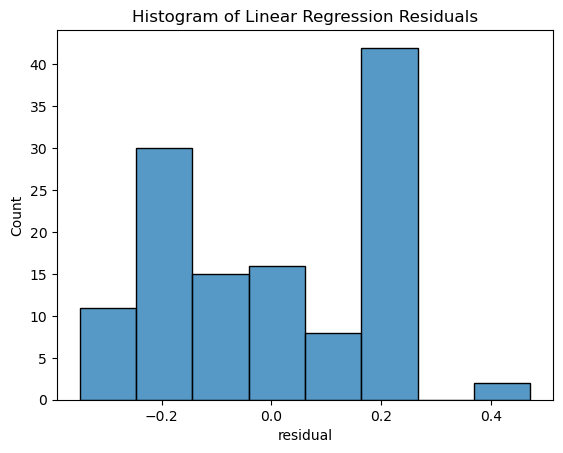

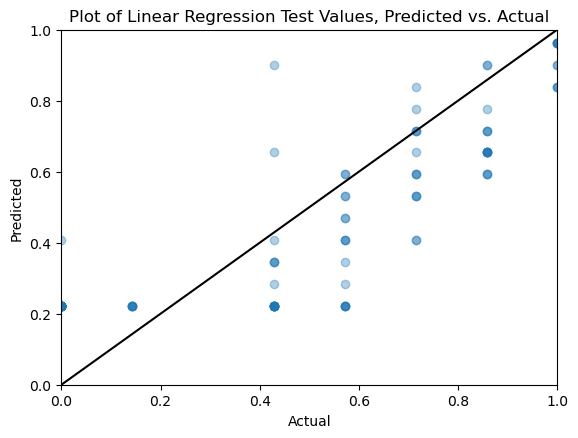

Shapiro-Wilk test:
Statistic: 0.8948333335836908
p-value: 7.328511492043768e-08
Residuals are NOT normally distributed
--------------------------------------------------------------------------------

Regression for: world_score 

Intercept: 0.14788553747423427
Slope: 0.19634791815936203
Sklearn R2 score: 0.19978572502721414


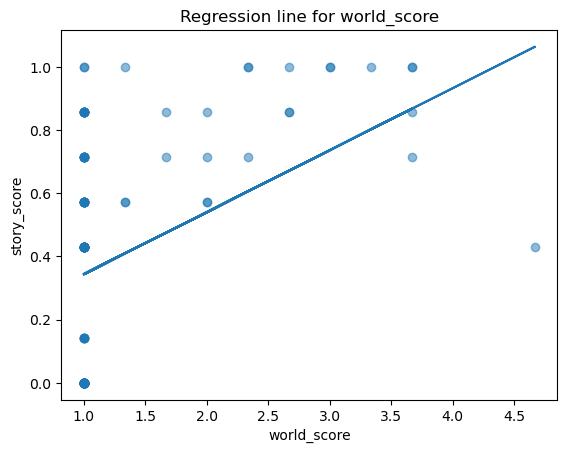

        predicted      actual    residual
count  124.000000  124.000000  124.000000
mean     0.401238    0.426267   -0.025030
std      0.141379    0.362953    0.323705
min      0.344233    0.000000   -0.655767
25%      0.344233    0.000000   -0.245133
50%      0.344233    0.428571   -0.084338
75%      0.344233    0.714286    0.344233
max      1.064176    1.000000    0.635604


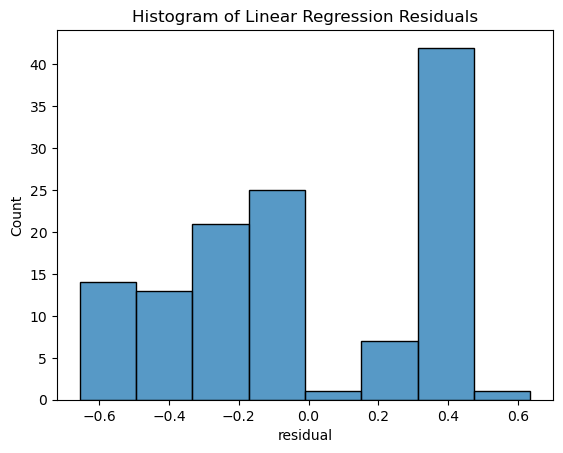

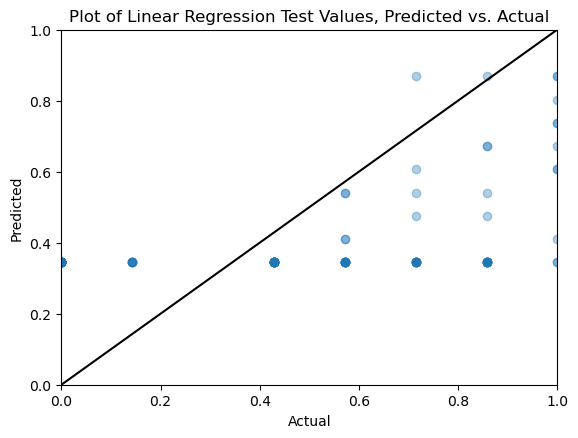

Shapiro-Wilk test:
Statistic: 0.8870214042308835
p-value: 3.0197341705663197e-08
Residuals are NOT normally distributed
--------------------------------------------------------------------------------

Regression for: suspense_score 

Intercept: -0.18988042515500403
Slope: 0.24429330633936466
Sklearn R2 score: 0.5482670393378332


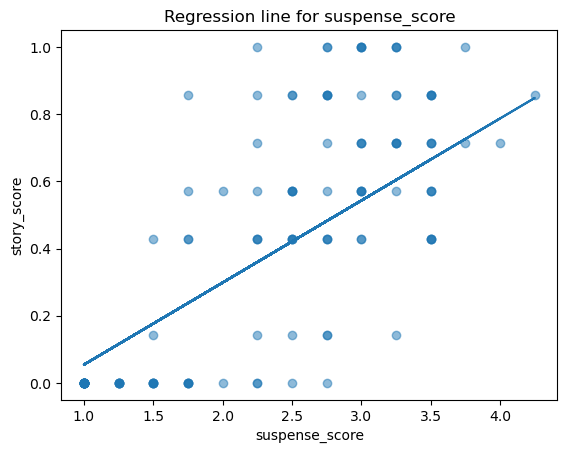

        predicted      actual    residual
count  124.000000  124.000000  124.000000
mean     0.387361    0.426267   -0.038906
std      0.218663    0.362953    0.240797
min      0.054413    0.000000   -0.640220
25%      0.176560    0.000000   -0.191997
50%      0.420853    0.428571    0.022289
75%      0.542999    0.714286    0.115486
max      0.848366    1.000000    0.481926


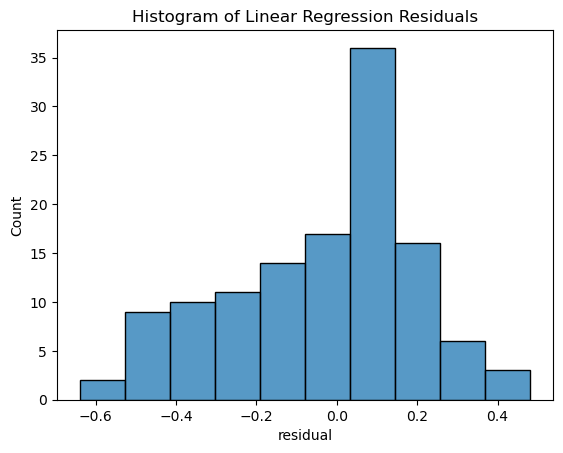

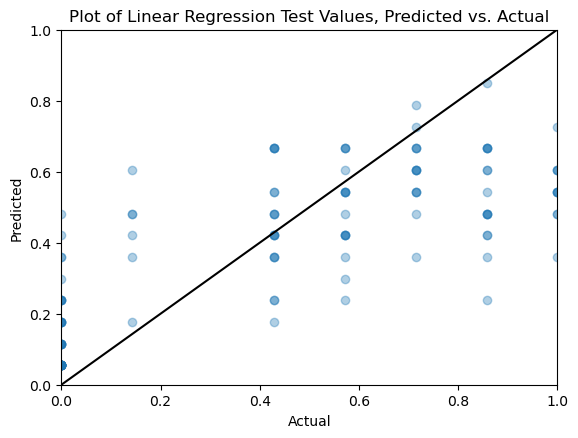

Shapiro-Wilk test:
Statistic: 0.9723627191711948
p-value: 0.011987965061998014
Residuals are NOT normally distributed
--------------------------------------------------------------------------------

Regression for: surprise_score 

Intercept: -0.1995212472854926
Slope: 0.23643933750595134
Sklearn R2 score: 0.35988020584577185


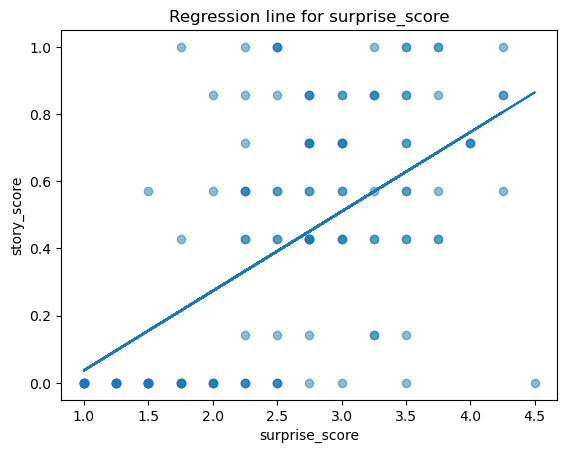

        predicted      actual    residual
count  124.000000  124.000000  124.000000
mean     0.408261    0.426267   -0.018006
std      0.209908    0.362953    0.289827
min      0.036918    0.000000   -0.785752
25%      0.258580    0.000000   -0.231585
50%      0.450687    0.428571    0.031950
75%      0.568907    0.714286    0.155138
max      0.864456    1.000000    0.864456


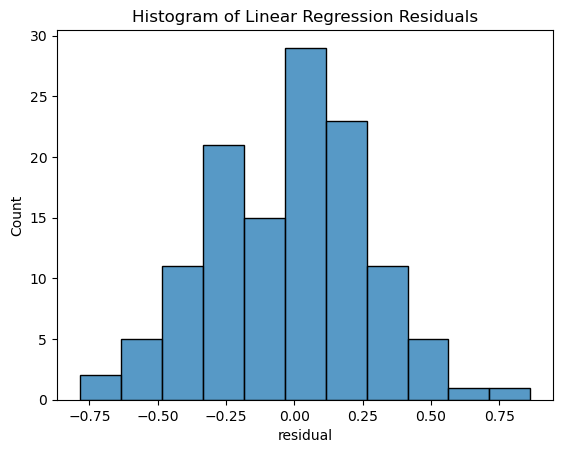

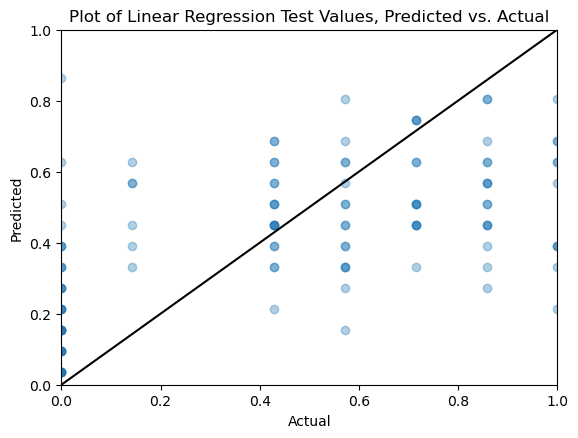

Shapiro-Wilk test:
Statistic: 0.9887953324037887
p-value: 0.40856440129094784
Residuals are approximately normally distributed
--------------------------------------------------------------------------------

Regression for: curiosity_score 

Intercept: -0.30040537320963123
Slope: 0.25793728652713444
Sklearn R2 score: 0.4438613536735162


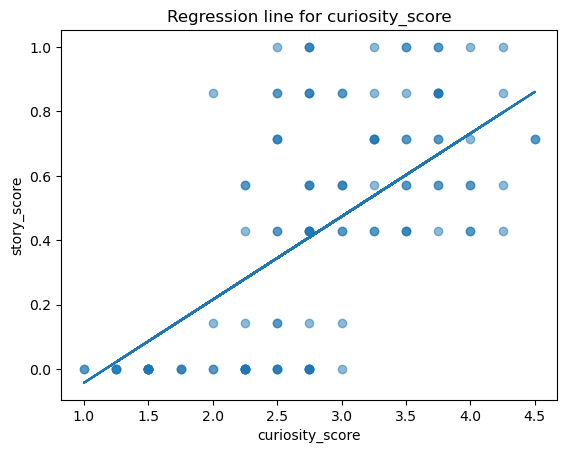

        predicted      actual    residual
count  124.000000  124.000000  124.000000
mean     0.417243    0.426267   -0.009025
std      0.216301    0.362953    0.270520
min     -0.042468    0.000000   -0.655562
25%      0.279954    0.000000   -0.179867
50%      0.408922    0.428571    0.026481
75%      0.602375    0.714286    0.180748
max      0.860312    1.000000    0.473406


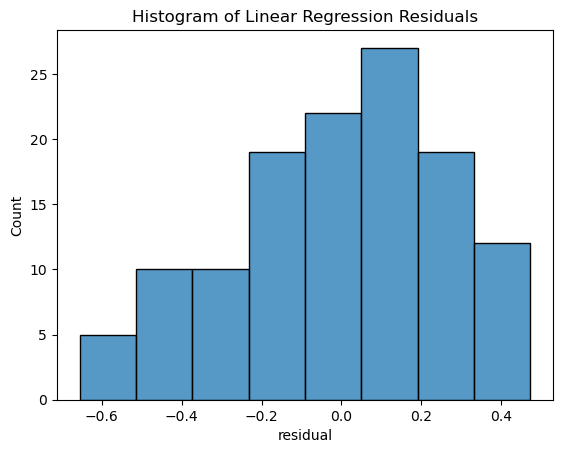

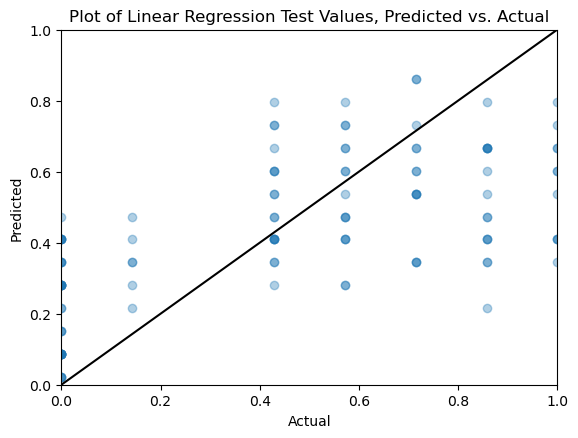

Shapiro-Wilk test:
Statistic: 0.9671919606763613
p-value: 0.004115575372726824
Residuals are NOT normally distributed
--------------------------------------------------------------------------------



In [37]:
# Run fuction for each independant variable
for feature in features:
    run_linear_regression(feature)